# Mel Spectrogram Preprocessing (GPU Accelerated)

This notebook preprocesses the **GTZAN Genre Dataset** (or similar) by converting each `.au` file  
into a **high-resolution log-mel spectrogram** saved as `.npy`, ready for CNN training.

## Main Features
- **High-detail Mel Spectrograms:** 1024 mel bands, 44.1 kHz, `n_fft=16384`, `hop=16`
- **GPU acceleration:** Uses `torchaudio` on CUDA / MPS for fast STFT computation  
- **Chunking:** Processes long files in segments to prevent VRAM overflow  
- **Precision:** Saved as `float16` for compactness (keeps ~80 dB dynamic range)  
- **Index file:** Builds a `index.json` listing all cached spectrograms and metadata


## Imports
- **json** — read and write the `index.json` metadata file for cached mel-spectrograms.  
- **random** — select random samples for visualization or testing.  
- **torch** — tensor operations and automatic device handling (CPU / GPU / MPS).  
- **torchaudio** — GPU/MPS-accelerated STFT, MelSpectrogram, and AmplitudeToDB transforms.  
- **numpy** — numerical arrays and saving `.npy` mel-spectrogram files.  
- **matplotlib.pyplot** — plotting and visualization of mel-spectrograms.  
- **torch.nn.functional (F)** — utilities like `pad` for short audio segments (< `n_fft`).  
- **pathlib.Path** — clean and portable path management.  
- **tqdm.auto.tqdm** — progress bars for classes and file processing loops.

## Constants
- **INPUT_ROOT** — source directory containing class subfolders and `.au` files.  
- **CACHE_ROOT** — output directory for cached `.npy` mel-spectrograms and `index.json`.

- **BACKEND** — feature type (`"mel"` for log-power Mel Spectrograms).  
- **COLORMAP** — color palette for spectrogram visualization (e.g., `"magma"`).  
- **SR** — target sample rate in Hz.  
- **N_FFT** — FFT window size (samples): larger = higher frequency resolution, slower.  
- **HOP** — hop length between frames: smaller = higher temporal resolution, more frames.  
- **N_MELS** — number of mel bands (vertical resolution of the spectrogram).  
- **FMIN / FMAX** — lower and upper frequency limits (Hz).  
- **DB_LO / DB_H** — fixed dB range for normalization and visualization (-90 to 0 dB).  
- **WINDOW** — window function used for STFT (e.g., `"hann"`).  
- **CHUNK_S** — audio chunk length (in seconds) to process sequentially and avoid VRAM overflow.  
- **W / H** — target width/height for optional rectangular display or UI rendering.  
- **CLASSES** — list of class subfolders automatically detected in `INPUT_ROOT`.  
- **INDEX** — dictionary collecting metadata (`classes`, `items`, `params`) for later use.  
- **DEVICE** — automatically selected compute device: CUDA → MPS (Apple) → CPU.

In [3]:
import json
import random
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

INPUT_ROOT = Path("../../data/dataset/classifier")
CACHE_ROOT = Path("../../data/dataset/classifier_mel")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)


BACKEND     = "mel"
COLORMAP    = "magma"
SR          = 44100
N_FFT       = 16384
HOP         = 16
N_MELS      = 1024
FMIN        = 20
FMAX        = SR // 2
DB_LO       = -90.0
DB_H        = 0.0
WINDOW      = "hann"
CHUNK_S     = 10.0
W           = 2048
H           = 1024
CLASSES     = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]
INDEX       = {"classes": [c.name for c in CLASSES], "items": [], "params": {"sr": SR, "n_fft": N_FFT, "hop": HOP, "n_mels": N_MELS, "fmin": FMIN, "fmax": FMAX, "backend": "mel_db"}}
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu"))


print(f"Using {DEVICE}")


Using mps


## GPU Mel Cache Builder — What this cell does

This cell converts every `.au` file in `CLASSES` into a **log-mel spectrogram** (float16) using **torchaudio** on the selected `DEVICE` (CUDA/MPS/CPU), and writes both the `.npy` files and an `index.json`.

### Pipeline
1. **Transforms on device**
   - `MelSpectrogram`: `SR`, `N_FFT`, `HOP`, `N_MELS`, `[FMIN, FMAX]`, `hann`, `center=False`.
   - `AmplitudeToDB`: fixed dynamic range (`DB_LO..DB_H`) for consistent scaling.
2. **Robust audio loading**
   - Mono mixdown and resampling to `SR`.
   - **Padding** if the signal (or last chunk) is shorter than `N_FFT`.
3. **Chunked processing**
   - Split into `CHUNK_S`-second chunks to control VRAM, compute mel+dB on the GPU, concatenate along time.
4. **Caching & metadata**
   - Save mel as `.npy` (float16) under `CACHE_ROOT/<class>/file.npy`.
   - Append entry to `INDEX["items"]` with paths, shapes, and class id.
   - Write `index.json` with classes and parameters.

### Why this design
- **Speed**: STFT/Mel on GPU; CPU only for I/O and saving.
- **Stability**: padding avoids STFT errors on short audio; fixed dB range gives comparable values across files.
- **Scalability**: chunking prevents OOM with large `N_FFT` / tiny `HOP`.

### Knobs to tune
- **Quality vs speed**: increase `N_FFT`/`N_MELS`, decrease `HOP` for detail; do the opposite for speed.
- **VRAM**: reduce `CHUNK_S` if you hit memory limits.
- **Disk**: keep float16; switch to float32 only if you need extra precision.

In [4]:

mel_tf = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP, win_length=N_FFT,
    f_min=float(FMIN), f_max=float(FMAX), n_mels=N_MELS,
    window_fn=torch.hann_window, power=2.0, center=False, norm=None, mel_scale="htk"
).to(DEVICE)

db_tf = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=abs(DB_LO)).to(DEVICE)

def load_mono_resampled(path: Path) -> torch.Tensor:
    wav, sr = torchaudio.load(str(path))
    if wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SR:
        wav = torchaudio.functional.resample(wav, sr, SR)
    return wav.contiguous()

@torch.inference_mode()
def mel_db_chunks(wav_cpu: torch.Tensor) -> np.ndarray:
    T = wav_cpu.shape[-1]
    if T < N_FFT:
        wav_cpu = F.pad(wav_cpu, (0, N_FFT - T))
        T = wav_cpu.shape[-1]
    chunk_len = int(CHUNK_S * SR)
    chunks = [wav_cpu[:, s:min(s+chunk_len, T)] for s in range(0, T, chunk_len)] if chunk_len > 0 else [wav_cpu]
    out = []
    for ch in chunks:
        x = ch.to(DEVICE)
        if x.shape[-1] < N_FFT:
            x = F.pad(x, (0, N_FFT - x.shape[-1]))
        S = mel_tf(x)                  
        S_db = db_tf(S).squeeze(0)     
        out.append(S_db.cpu())
    X = torch.cat(out, dim=1).numpy().astype(np.float32)  
    X = np.nan_to_num(X, nan=DB_LO, neginf=DB_LO, posinf=DB_H)
    return X

outer = tqdm(CLASSES, desc="Classes", position=0, dynamic_ncols=True)
for ci, cdir in enumerate(outer):
    out_dir = CACHE_ROOT / cdir.name
    out_dir.mkdir(parents=True, exist_ok=True)
    files = sorted(list(cdir.glob("*.au")))
    inner = tqdm(files, desc=cdir.name, position=1, leave=False, dynamic_ncols=True)
    for f in tqdm(inner):
        try:
            wav = load_mono_resampled(f)
            X = mel_db_chunks(wav)                 
            X16 = X.astype(np.float16)
            out_npy = out_dir / (f.stem + ".npy")
            np.save(out_npy, X16)
            INDEX["items"].append({
                "mel_path": str(out_npy),
                "class_idx": ci,
                "n_mels": int(X16.shape[0]),
                "n_frames": int(X16.shape[1]),
                "stem": f.stem
            })
        except Exception as e:
            print(f"[WARN] {f.name}: {e}")
    inner.close()
outer.close()

with open(CACHE_ROOT / "index.json", "w") as fp:
    json.dump(INDEX, fp)

print(f"Done. Cached mel in: {CACHE_ROOT} — items: {len(INDEX['items'])}")

Classes:   0%|          | 0/10 [00:00<?, ?it/s]




































































































Classes:  10%|█         | 1/10 [04:55<44:19, 295.54s/it]




































































































Classes:  20%|██        | 2/10 [10:28<42:19, 317.49s/it]




































































































Classes:  30%|███       | 3/10 [31:33<1:27:32, 750.40s/it]




































































































Classes:  40%|████      | 4/10 [47:54<1:24:08, 841.45s/it]




































































































Classes:  50%|█████     | 5/10 [1:33:59<2:07:54, 1534.88s/it]




































































































Classes:  60%|██████    | 6/10 [2:08:18<1:54:12, 1713.16s/

Done. Cached mel in: ../../data/dataset/classifier_mel — items: 1000



Two random **mel-spectrograms** sampled from the GPU-generated cache (`.npy` files).  
Each represents one full audio clip from the dataset, processed with:

- **Sample rate:** 44.1 kHz  
- **FFT window:** 16384 samples  
- **Hop length:** 16 samples  
- **Mel bins:** 1024  
- **dB range:** −90 → 0  
- **Device:** CUDA / MPS / CPU (auto-selected)  

These parameters yield extremely detailed time–frequency representations,  
suitable for CNN-based genre or style classification.

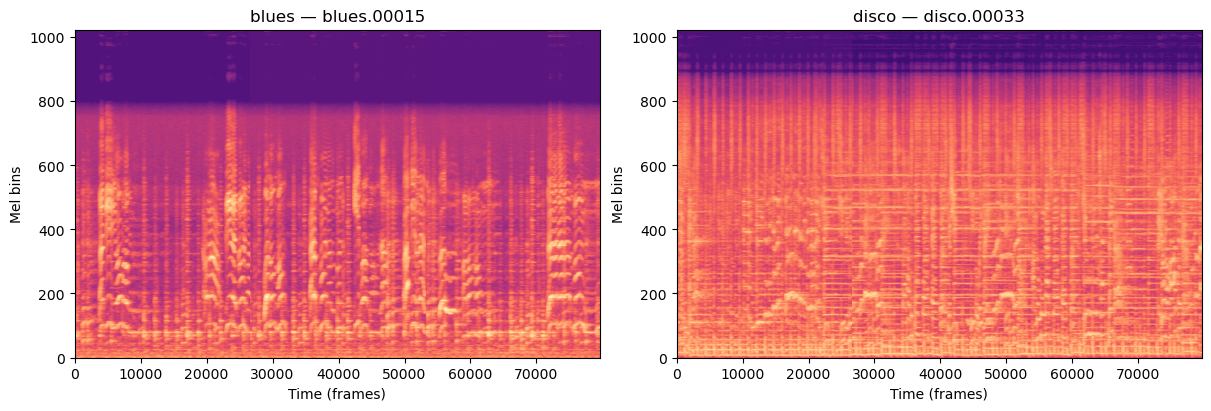

In [6]:
with open(f"{CACHE_ROOT}/index.json") as f:
    idx = json.load(f)
classes = idx["classes"]
items = idx["items"]

samples = random.sample(items, 2)

fig, axs = plt.subplots(1, 2, figsize=(12,4), constrained_layout=True)
for ax, it in zip(axs, samples):
    X = np.load(it["mel_path"]).astype(np.float32)   
    ax.imshow(X, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{classes[it['class_idx']]} — {it['stem']}")
    ax.set_xlabel("Time (frames)"); ax.set_ylabel("Mel bins")
plt.show()

- **Harmonic patterns** → horizontal lines (typical in tonal/instrumental genres).  
- **Percussive activity** → vertical energy streaks (common in rhythmic music).  
- **Spectral balance** → energy concentration across low/mid/high mel bands.  
- **Chunk transitions** → slight contrast shifts caused by segmented processing.  